# Computer Price Prediction — Feature Engineering

**Master's in Applied Artificial Intelligence (MNA)** · Tecnológico de Monterrey
Course TC5053 — Data Science and Analytics · Week 6: Feature Engineering (FE)

**Team 16**
- Jose Antonio Garcia Arroyo
- Omar Israel Galván García
- Miguel Angel Garcia Bautista
- Ricardo Martín Galván Páez

---

## Overview

This notebook prepares the `computer_prices.csv` dataset (100,000 laptops and desktops, 27 raw columns, available on Kaggle) for a price-regression model. The **target variable** is `price`.

| Step | Section | Technique |
|---|---|---|
| 1 | Data loading and inspection | `info()`, cardinality check, drop high-cardinality columns |
| 2 | Exploratory data analysis | Duplicates, missing values, descriptive statistics, histograms, bar charts |
| 3 | Correlation analysis | Correlation heatmap, removal of redundant variables (\|r\| > 0.9) |
| 4 | Feature creation | `years_since_release`, quantile binning of `vram_gb` |
| 5 | Feature combination | `power_watts` from `charger_watts` + `psu_watts` |
| 6 | Skew reduction | Log vs. square root vs. Box-Cox |
| 7 | Scaling | `MinMaxScaler` |
| 8 | Ordinal encoding | `wifi` with `OrdinalEncoder` |
| 9 | Binary encoding | `gpu_model` with `BinaryEncoder` |
| 10 | One-hot encoding | Remaining categorical variables, final dataset check |

**Running the notebook:** it runs in Google Colab (the CSV is read from Google Drive) or locally (place the CSV at `data/computer_prices.csv`).

## Dataset description

The dataset contains technical specifications and prices of laptops and desktop computers, collected to analyze device performance and pricing. It covers hardware, storage, connectivity and other specifications.

| Column | Description |
|---|---|
| `device_type` | Device type (e.g., laptop, desktop) |
| `brand` | Device brand |
| `model` | Device model |
| `release_year` | Year the device was released |
| `os` | Installed operating system |
| `form_factor` | Form factor or design (e.g., laptop, ultrabook, desktop tower) |
| `cpu_brand` | Processor brand |
| `cpu_model` | Processor model |
| `cpu_tier` | Processor performance tier, ordinal from 1 to 6 |
| `cpu_cores` | Number of processor cores |
| `cpu_threads` | Number of processor threads |
| `gpu_brand` | Graphics card brand |
| `gpu_model` | Specific graphics card model |
| `gpu_tier` | GPU performance tier, ordinal from 1 to 6 |
| `vram_gb` | GPU video memory (GB) |
| `ram_gb` | System memory (GB) |
| `storage_type` | Storage type (e.g., HDD, SSD) |
| `storage_gb` | Storage capacity (GB) |
| `storage_drive_count` | Number of installed storage drives |
| `display_type` | Display type (e.g., IPS, TN, OLED) |
| `charger_watts` | Charger power (W), laptops only |
| `psu_watts` | Power supply unit power (W), desktops only |
| `wifi` | Wi-Fi standard (e.g., Wi-Fi 5, 6, 6E, 7) |
| `bluetooth` | Bluetooth version |
| `weight_kg` | Device weight (kg) |
| `warranty_months` | Warranty duration (months) |
| `price` | Device price. **Target variable** to be predicted by the downstream model |

---

## 0. Setup

In [ ]:
# Install required libraries
!pip install category_encoders

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
)
from category_encoders.binary import BinaryEncoder

---

## 1. Data loading and initial inspection

**Goals**
- Load all records into a dataframe (`computers_df`).
- Summarize the data types with `info()`: how many columns are numeric and how many are text?
- Count the unique values per column.
- Drop the following columns:
  - `model`: extremely high cardinality, which makes it impractical for analysis and modeling.
  - `cpu_model`: also very high cardinality, and its information is already captured implicitly by `cpu_tier`, `cpu_cores` and `cpu_threads`.

In [ ]:
# Data location: Google Drive when running in Colab, ./data/ when running locally
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = "/content/drive/MyDrive/Mna/Analítica de datos/computer_prices.csv"
except ImportError:
    DATA_PATH = "data/computer_prices.csv"  # local run: place the CSV in ./data/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the dataset
computers_df = pd.read_csv(DATA_PATH)
computers_df.info()
computers_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  object 
 12  gpu_model            100000 non-null  object 
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null  int64  
 15  ram_gb            

(100000, 27)

In [ ]:
num_cols = computers_df.select_dtypes(include=np.number).columns
cat_cols = computers_df.select_dtypes(exclude=np.number).columns

print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical/text columns: {len(cat_cols)}")

Numeric columns: 15
Categorical/text columns: 12


**Result:** 15 numeric and 12 text columns.

In [ ]:
# Unique values per column
print("Unique values per column:")
print(computers_df.nunique().to_string())

# Drop high-cardinality columns
computers_df.drop(columns=['model', 'cpu_model'], inplace=True)
print(f'Shape after dropping columns: {computers_df.shape}')

Unique values per column:
device_type                2
brand                     10
model                  99036
release_year               8
os                         4
form_factor               10
cpu_brand                  3
cpu_model              26971
cpu_tier                   6
cpu_cores                 12
cpu_threads               25
gpu_brand                  4
gpu_model                 49
gpu_tier                   6
vram_gb                    8
ram_gb                    15
storage_type               4
storage_gb                 5
storage_drive_count        4
display_type               6
charger_watts              7
psu_watts                  9
wifi                       4
bluetooth                  5
weight_kg                 47
warranty_months            4
price                   3366
Shape after dropping columns: (100000, 25)


---

## 2. Exploratory data analysis (univariate)

**Goals**
- Check for duplicate and missing values.
- Compute descriptive statistics, separately for numeric and categorical variables (including frequency tables for the latter).
- Plot histograms for the numeric variables and bar charts for the categorical ones (top 10 values only for high-cardinality variables).

In [ ]:
n_duplicates = computers_df.duplicated().sum()
print(f"Duplicate records: {n_duplicates}")

Duplicate records: 0


In [ ]:
missing_df = pd.DataFrame({
    "n_missing": computers_df.isnull().sum(),
    "percentage": computers_df.isnull().mean() * 100
}).sort_values(by="n_missing", ascending=False)
missing_df

,n_missing,percentage
device_type,0,0.0
brand,0,0.0
release_year,0,0.0
os,0,0.0
form_factor,0,0.0
cpu_brand,0,0.0
cpu_tier,0,0.0
cpu_cores,0,0.0
cpu_threads,0,0.0
gpu_brand,0,0.0


**Result:** the dataset contains no duplicate records and no missing values.

### Numeric variables: descriptive statistics, skew and kurtosis

In [ ]:
numeric_columns = computers_df.select_dtypes(include=[np.number]).columns
categorical_columns = computers_df.select_dtypes(exclude=[np.number]).columns

describe_df = computers_df[numeric_columns].describe().T
describe_df['skew'] = computers_df[numeric_columns].skew()
describe_df['kurtosis']= computers_df[numeric_columns].kurtosis()
describe_df

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
release_year,100000.0,2022.320850,2.025761,2018.00,2021.00,2023.00,2024.00,2025.00,-0.479062,-0.715846
cpu_tier,100000.0,3.153490,1.373175,1.00,2.00,3.00,4.00,6.00,0.174307,-0.751699
cpu_cores,100000.0,10.515740,5.044092,4.00,6.00,8.00,14.00,28.00,1.087762,1.007646
cpu_threads,100000.0,19.372700,9.718426,4.00,12.00,16.00,24.00,56.00,1.125744,1.300012
gpu_tier,100000.0,2.991350,1.459643,1.00,2.00,3.00,4.00,6.00,0.285752,-0.851269
vram_gb,100000.0,6.152180,3.964926,0.00,4.00,6.00,8.00,16.00,0.281362,-0.354864
ram_gb,100000.0,39.706400,31.902684,8.00,16.00,32.00,64.00,144.00,1.049278,0.195870
storage_gb,100000.0,903.936000,774.243654,256.00,512.00,512.00,1024.00,4096.00,2.304037,6.272154
storage_drive_count,100000.0,1.524980,0.797284,1.00,1.00,1.00,2.00,4.00,1.540038,1.746179
charger_watts,100000.0,61.383450,62.795034,0.00,0.00,65.00,90.00,240.00,0.855735,0.238015


### Categorical variables: descriptive statistics and frequency tables

In [ ]:
for col in categorical_columns:
    print(f"\n{col}")
    display(computers_df[col].describe())
    display(computers_df[col].value_counts(dropna=False))


device_type


,device_type
count,100000
unique,2
top,Laptop
freq,59844


,count
device_type,
Laptop,59844
Desktop,40156



brand


,brand
count,100000
unique,10
top,Lenovo
freq,15992


...

,display_type
count,100000
unique,6
top,LED
freq,32000


,count
display_type,
LED,32000
OLED,21910
IPS,17742
Mini-LED,12188
QLED,10069
VA,6091



wifi


,wifi
count,100000
unique,4
top,Wi-Fi 6
freq,46149


,count
wifi,
Wi-Fi 6,46149
Wi-Fi 6E,25923
Wi-Fi 5,19926
Wi-Fi 7,8002


### Distributions

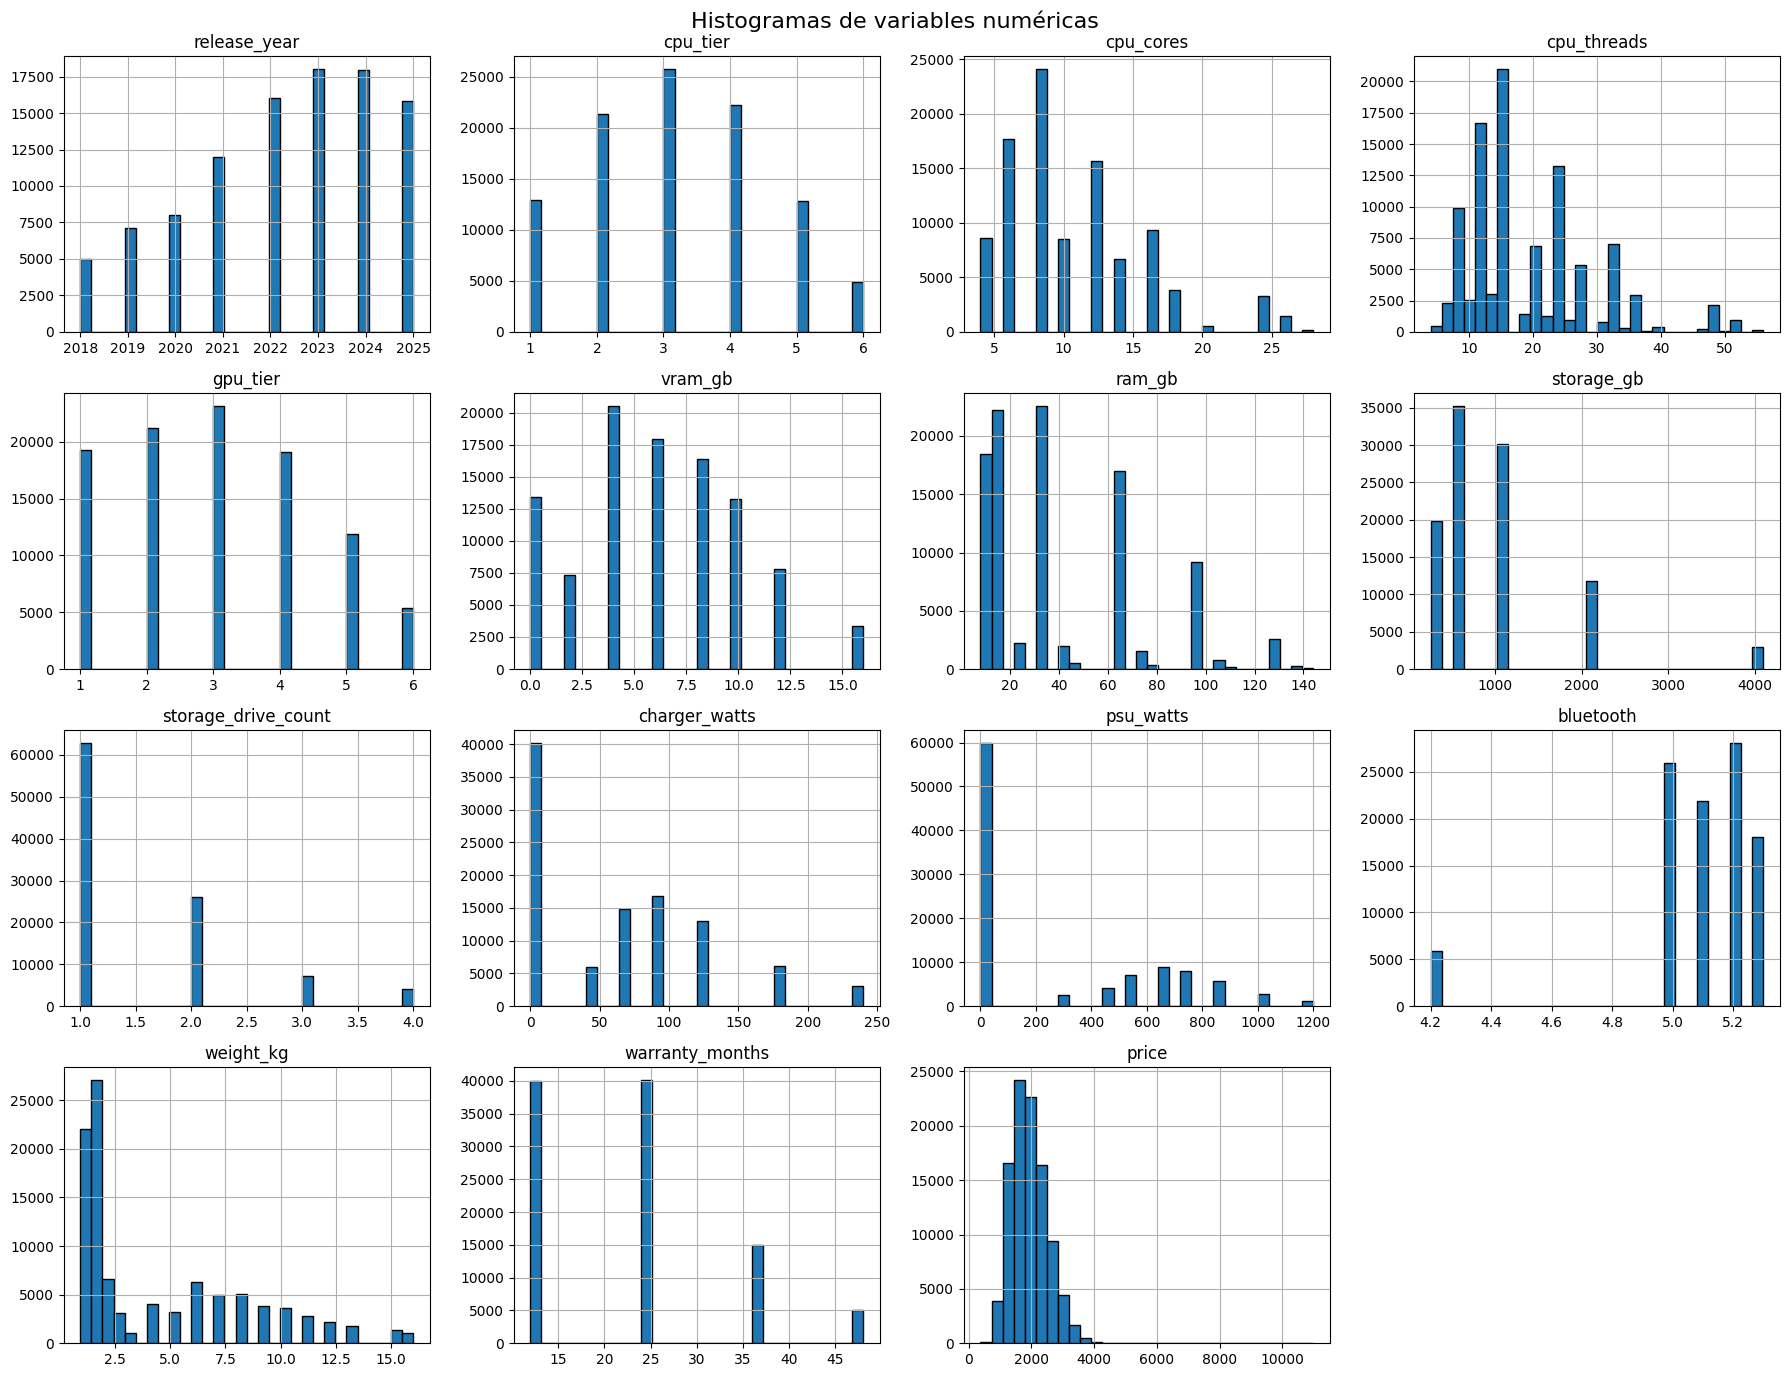

In [ ]:
computers_df[numeric_columns].hist(
    figsize=(18, 14),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Histograms of numeric variables", fontsize=16)
plt.tight_layout()
plt.show()

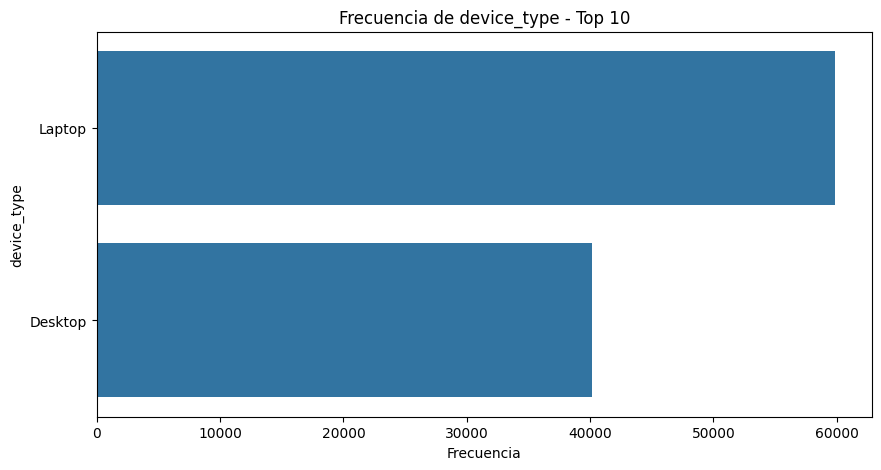

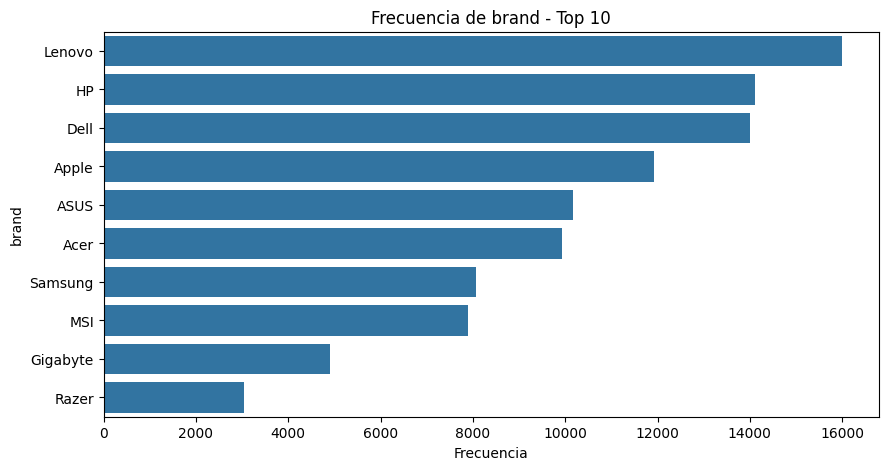

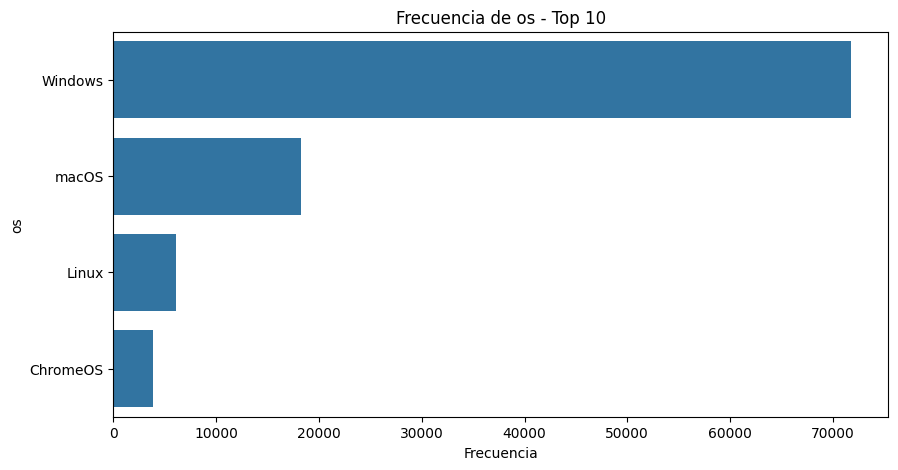

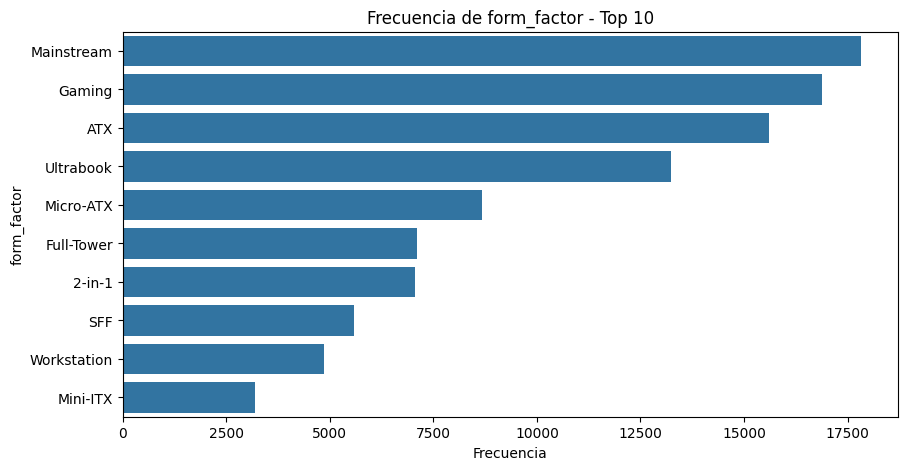

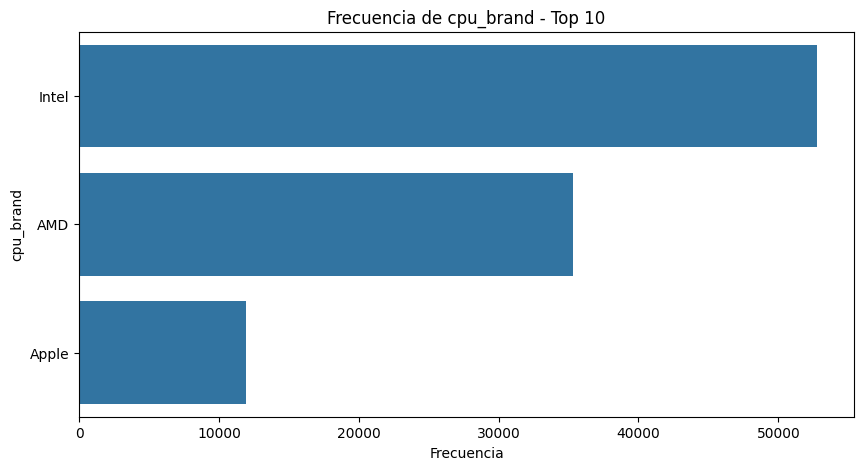

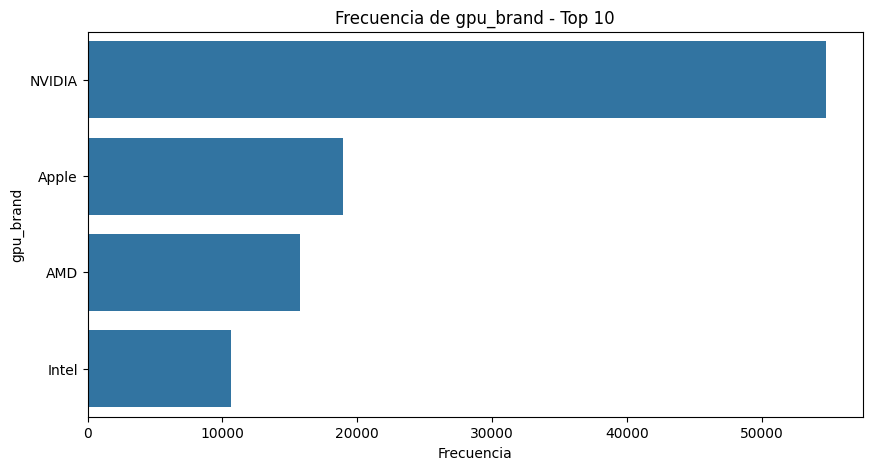

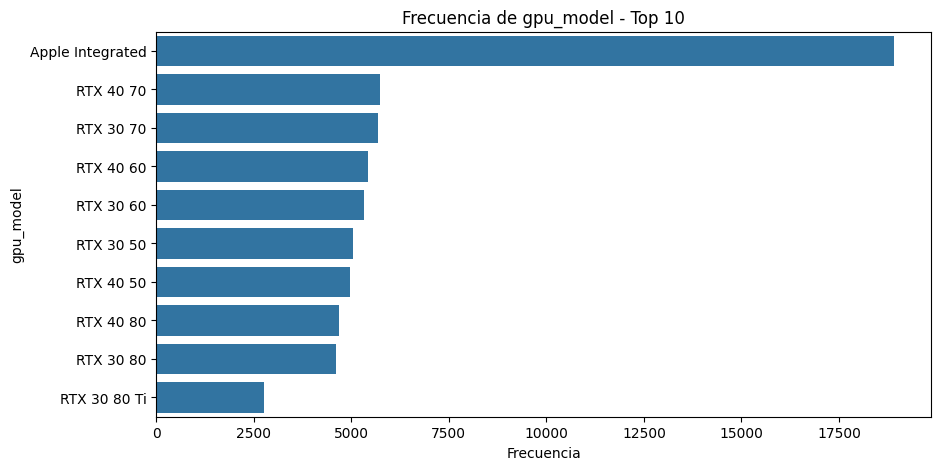

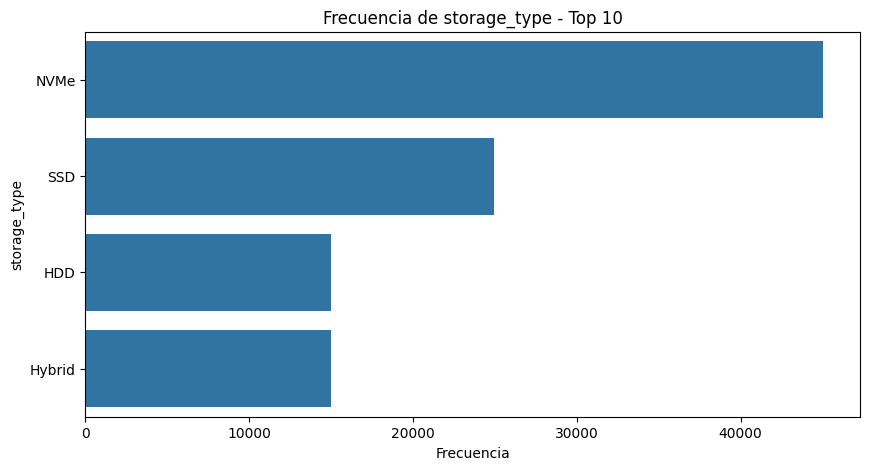

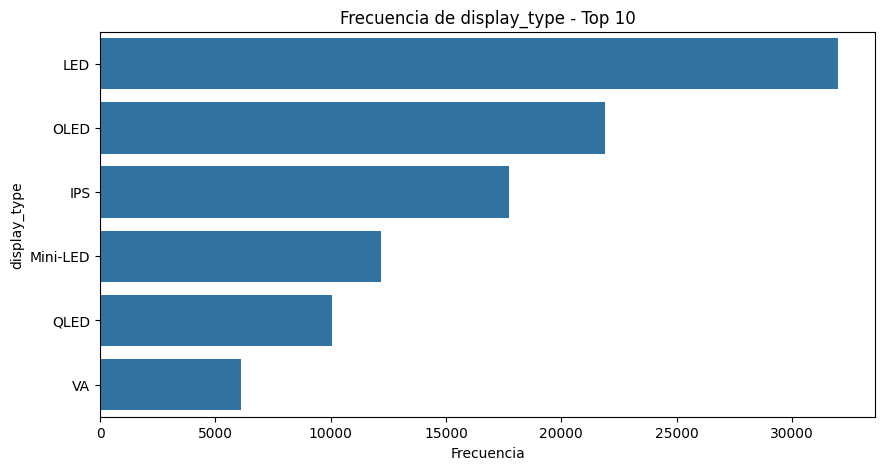

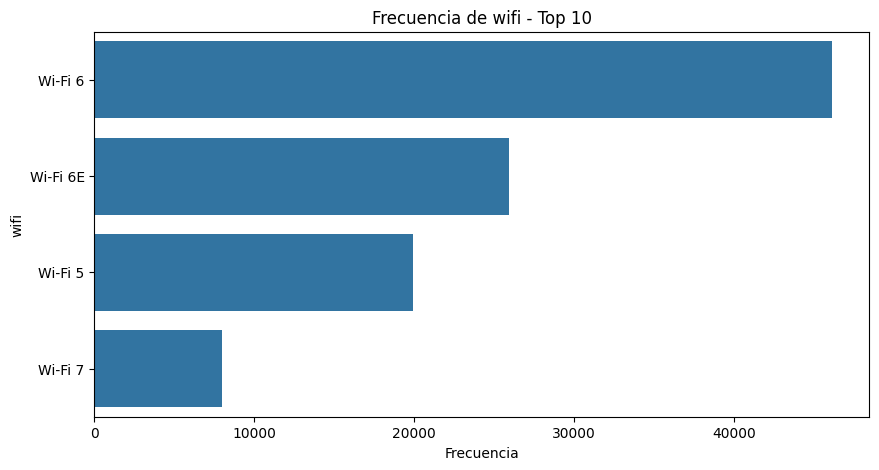

In [ ]:
for col in categorical_columns:
    plt.figure(figsize=(10, 5))

    top_values = computers_df[col].value_counts().head(10)

    sns.barplot(
        x=top_values.values,
        y=top_values.index
    )

    plt.title(f"Frequency of {col} — Top 10")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

---

## 3. Correlation analysis and redundancy removal

**Goals**
- Draw a heatmap of the correlation matrix of the numeric variables.
- Identify and print the variable pairs with a correlation above 0.9.
- Keep the variables that best represent overall hardware capability and drop the rest as redundant.
- Justify the decisions.

In [ ]:
correlation = computers_df[numeric_columns].corr()
correlation

,release_year,cpu_tier,cpu_cores,cpu_threads,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,price
release_year,1.000000,-0.003788,-0.002468,-0.003357,-0.002626,-0.005210,-0.002416,-0.003399,0.000310,-0.000639,-0.001268,0.002489,-0.000905,-0.004031,0.089721
cpu_tier,-0.003788,1.000000,0.937376,0.848197,0.857225,0.409049,0.899349,0.001006,-0.004603,0.003966,-0.005501,-0.001991,-0.004079,0.000008,0.759196
cpu_cores,-0.002468,0.937376,1.000000,0.898171,0.812393,0.380896,0.906770,0.001004,0.016125,-0.028873,0.032949,-0.000568,0.030376,0.000015,0.720464
cpu_threads,-0.003357,0.848197,0.898171,1.000000,0.735096,0.556134,0.813155,0.000832,0.014963,-0.027150,0.031746,-0.002445,0.029261,0.000063,0.577503
gpu_tier,-0.002626,0.857225,0.812393,0.735096,1.000000,0.498624,0.912918,-0.003123,0.051215,-0.078105,0.090594,-0.000242,0.083700,-0.002593,0.762875
vram_gb,-0.005210,0.409049,0.380896,0.556134,0.498624,1.000000,0.441475,0.003355,0.030479,-0.044648,0.050708,-0.001494,0.046039,0.001302,0.305017
ram_gb,-0.002416,0.899349,0.906770,0.813155,0.912918,0.441475,1.000000,-0.001190,0.023607,-0.039456,0.045059,-0.000578,0.042133,-0.002225,0.758654
storage_gb,-0.003399,0.001006,0.001004,0.000832,-0.003123,0.003355,-0.001190,1.000000,0.001392,0.002160,-0.004137,0.000408,-0.004279,-0.004392,0.088937
storage_drive_count,0.000310,-0.004603,0.016125,0.014963,0.051215,0.030479,0.023607,0.001392,1.000000,-0.426559,0.500057,0.002185,0.454040,-0.003646,-0.082437
charger_watts,-0.000639,0.003966,-0.028873,-0.027150,-0.078105,-0.044648,-0.039456,0.002160,-0.426559,1.000000,-0.751078,-0.001489,-0.686176,0.005589,0.126309


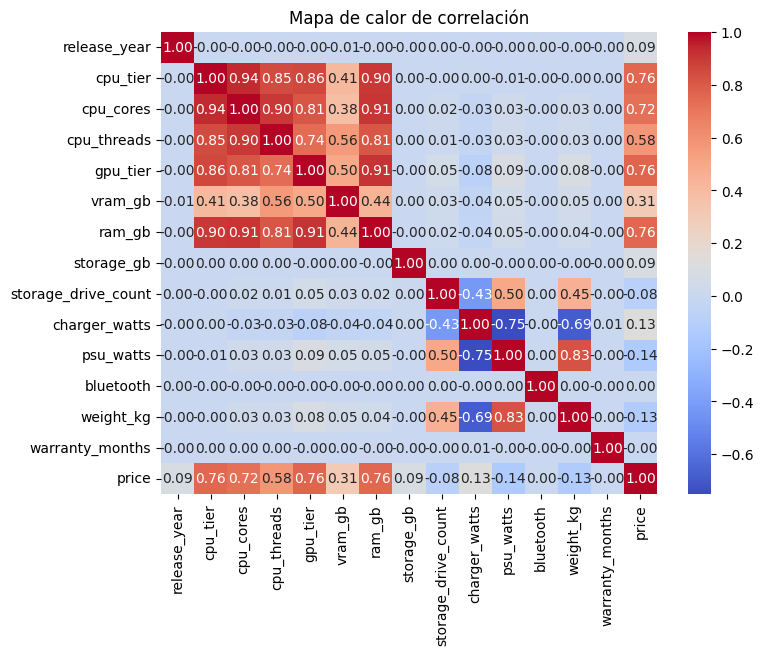

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    xticklabels=correlation.columns,
    yticklabels=correlation.columns
)

plt.title('Correlation heatmap')
plt.show()

In [ ]:
corr_pairs = []

for i in range(len(correlation.columns)):
    for j in range(i + 1, len(correlation.columns)):
        var1 = correlation.columns[i]
        var2 = correlation.columns[j]
        corr_value = correlation.iloc[i, j]

        if abs(corr_value) > 0.9:
            corr_pairs.append([var1, var2, corr_value])

corr_pairs_df = pd.DataFrame(
    corr_pairs,
    columns=["Variable 1", "Variable 2", "Correlation"]
)

print("Variable pairs with |correlation| > 0.9:")
corr_pairs_df

Variable pairs with |correlation| > 0.9:


,Variable 1,Variable 2,Correlation
0,cpu_tier,cpu_cores,0.937376
1,cpu_cores,ram_gb,0.906770
2,gpu_tier,ram_gb,0.912918


**Decision.** The pairs above the threshold are (`cpu_tier`, `cpu_cores`), (`cpu_cores`, `ram_gb`) and (`gpu_tier`, `ram_gb`).

- `cpu_tier` and `gpu_tier` are **kept**: they are ordinal variables that summarize the overall performance level of the processor and the graphics card.
- `cpu_cores` is **dropped**: it is highly correlated with `cpu_tier` and therefore adds redundant information.
- `ram_gb` is **dropped**: it is very highly correlated with both `gpu_tier` and `cpu_cores`, meaning that in this dataset it is strongly tied to higher-performance configurations.

In [ ]:
# Drop redundant variables (see rationale above)
drop_columns = ["cpu_cores", "ram_gb"]
computers_df = computers_df.drop(columns=drop_columns)
computers_df.shape

(100000, 23)

---

## 4. Feature creation: years since release and quantile binning

**Goals**
- Create a copy of the dataframe, `computers_transf`, to hold all transformations.
- Compute the years elapsed since each computer's release, store them in `years_since_release` and drop the original `release_year` column.
- Use `KBinsDiscretizer` to replace `vram_gb` with 4 ordinal, quantile-based bins.
- Print the bin edges and plot the number of observations per bin to understand how the data was grouped.

In [ ]:
# Work on a copy of the dataframe for feature engineering
computers_transf = computers_df.copy()

# Years since release (fixed reference year, so the result does not depend on when the notebook runs)
REFERENCE_YEAR = 2026
computers_transf['years_since_release'] = REFERENCE_YEAR - computers_transf['release_year']
computers_transf.drop(columns=['release_year'], inplace=True)
print(f'Shape after adding years_since_release: {computers_transf.shape}')

Shape after adding years_since_release: (100000, 23)


Bin edges (vram_gb):
  Bin 0: [0.0, 4.0)
  Bin 1: [4.0, 6.0)
  Bin 2: [6.0, 8.0)
  Bin 3: [8.0, 16.0)


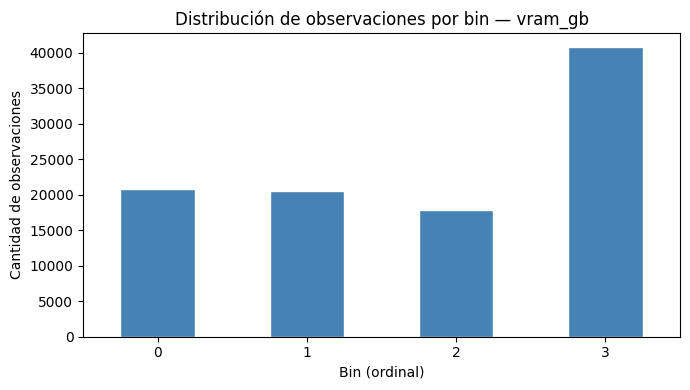

In [ ]:
# KBinsDiscretizer for vram_gb: 4 ordinal bins based on quantiles
kbd = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
computers_transf['vram_gb'] = kbd.fit_transform(computers_transf[['vram_gb']]).astype(int)

# Bin edges
print('Bin edges (vram_gb):')
edges = kbd.bin_edges_[0]
for i in range(len(edges) - 1):
    print(f'  Bin {i}: [{edges[i]:.1f}, {edges[i+1]:.1f})')

plt.figure(figsize=(7, 4))
computers_transf['vram_gb'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Observations per bin — vram_gb')
plt.xlabel('Bin (ordinal)')
plt.ylabel('Number of observations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---

## 5. Combining mutually exclusive power variables

**Goals**
- Explain the spike at 0 in the `charger_watts` and `psu_watts` histograms and what it means for each device type.
- Combine both variables into a single `power_watts` column and verify with a histogram that its distribution is bimodal.
- Drop the original `charger_watts` and `psu_watts` columns.

**Analysis.** Both histograms in Section 2 show a bar at 0. This happens because the two variables are **mutually exclusive by device type**:

- **Laptops** have a charger (`charger_watts` > 0) but no power supply unit, so `psu_watts = 0`.
- **Desktops** have a power supply unit (`psu_watts` > 0) but no charger, so `charger_watts = 0`.

Since exactly one of the two is non-zero for every record, their sum gives the power rating of each device.

Zeros in power_watts: 0


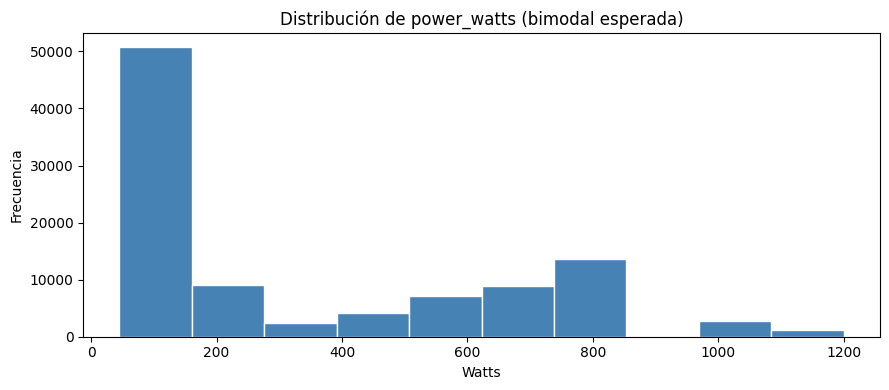

Shape after dropping the original columns: (100000, 22)


In [ ]:
# Combine the two mutually exclusive power variables
computers_transf['power_watts'] = computers_transf['charger_watts'] + computers_transf['psu_watts']
print(f"Zeros in power_watts: {(computers_transf['power_watts']==0).sum()}")


plt.figure(figsize=(9, 4))
plt.hist(computers_transf['power_watts'], bins=10, color='steelblue', edgecolor='white')
plt.title('Distribution of power_watts (bimodal expected)')
plt.xlabel('Watts')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


computers_transf.drop(columns=['charger_watts','psu_watts'], inplace=True)
print(f'Shape after dropping the original columns: {computers_transf.shape}')

A bimodal distribution is expected because two mutually exclusive variables were added together: laptop charger wattages and desktop PSU wattages form two separate peaks.

---

## 6. Reducing skew

**Goals**
- Reduce the skewness of `price` by comparing three transformers: logarithm, square root and Box-Cox. Each is applied to `price` and stored in a temporary variable, so the effects can be compared before choosing one.
- For the original variable and each transformation, report:
  - **Histogram**: shape of the distribution.
  - **Boxplot**: potential outliers.
  - **Q-Q plot**: closeness to normality.
  - **Skew**: asymmetry of the distribution.
  - **Outlier count**: number of extreme values (1.5 × IQR rule).
- Choose the transformation with the best effect and apply it to the continuous variables `weight_kg`, `power_watts` and `price`.

In [ ]:
log_transformer = FunctionTransformer(np.log)
sqrt_transformer = FunctionTransformer(np.sqrt)
boxcox_transformer = PowerTransformer(method="box-cox", standardize=False)
price_original = computers_transf["price"]


if (computers_transf['price'] <= 0).any():
    raise ValueError("Box-Cox requires strictly positive values, but 'price' contains values <= 0.")

price_log = log_transformer.fit_transform(computers_transf[["price"]])
price_sqrt = sqrt_transformer.fit_transform(computers_transf[["price"]])
price_boxcox = boxcox_transformer.fit_transform(computers_transf[["price"]])

In [ ]:
price_comparison = pd.DataFrame({
    "price_original": price_original,
    "price_log": price_log.iloc[:, 0],
    "price_sqrt": price_sqrt.iloc[:, 0],
    "price_boxcox": price_boxcox.flatten()
})

price_comparison.head()

,price_original,price_log,price_sqrt,price_boxcox
0,1383.99,7.232726,37.202016,13.084409
1,2274.99,7.729731,47.696855,14.616126
2,1879.99,7.539022,43.358851,14.014803
3,1331.99,7.194429,36.496438,12.971066
4,2681.99,7.894314,51.787933,15.149121


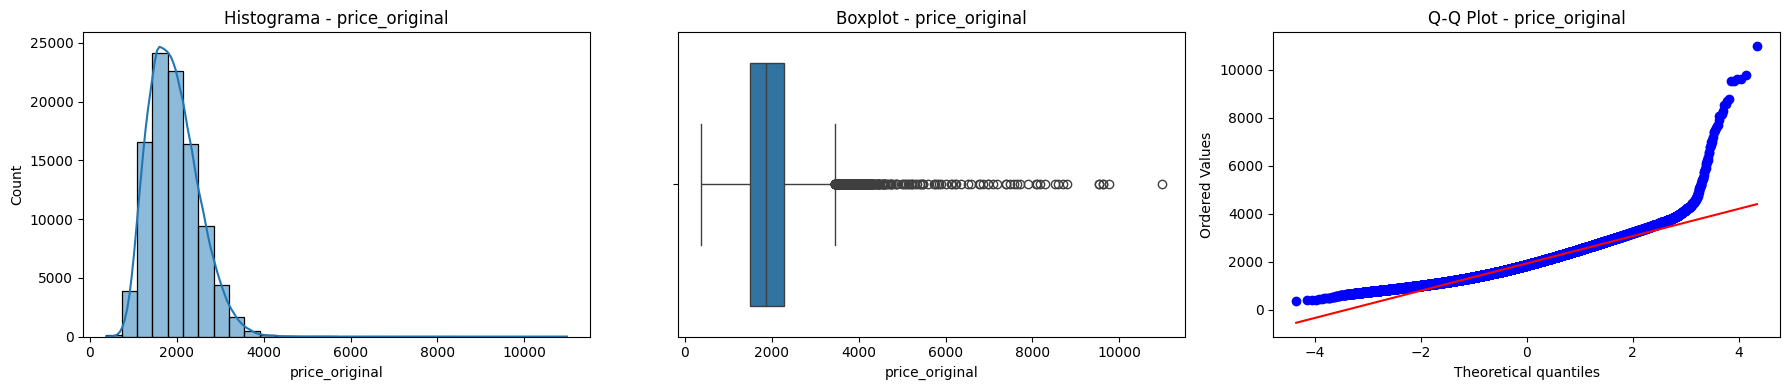

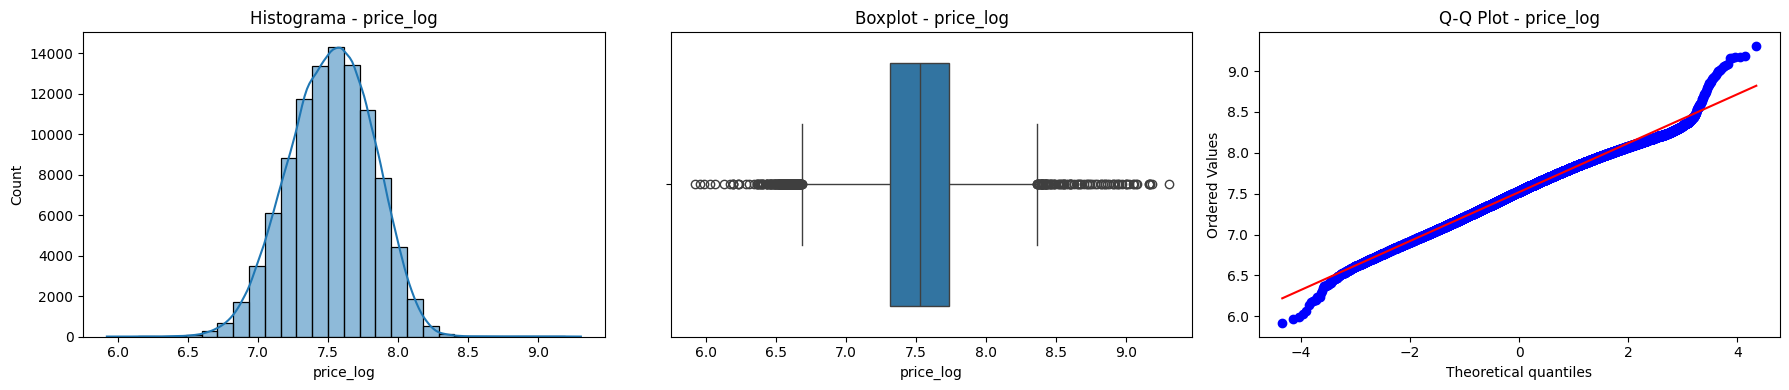

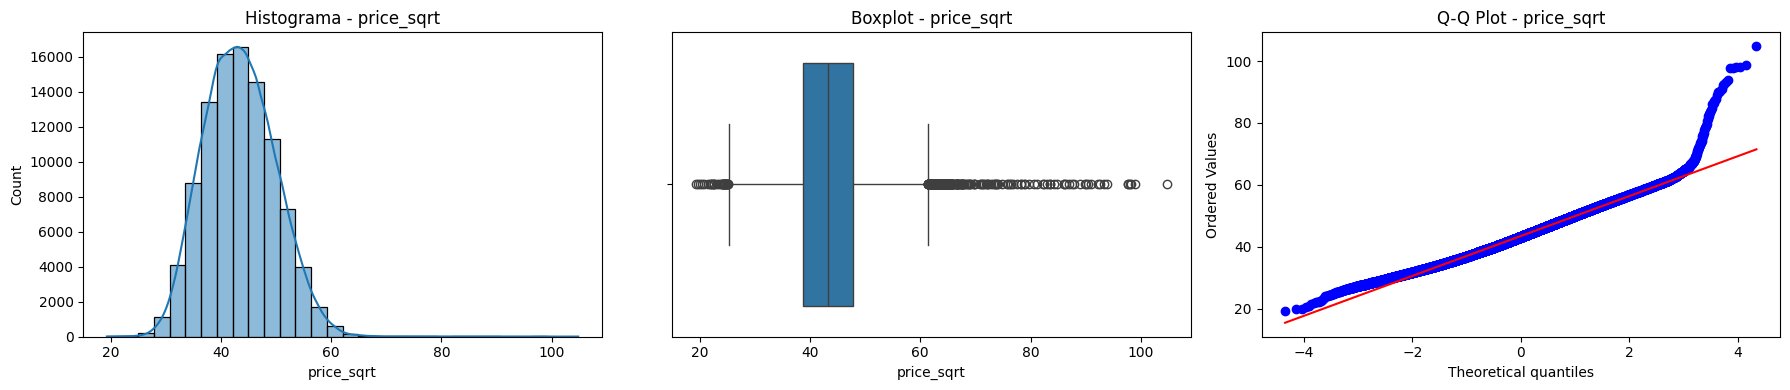

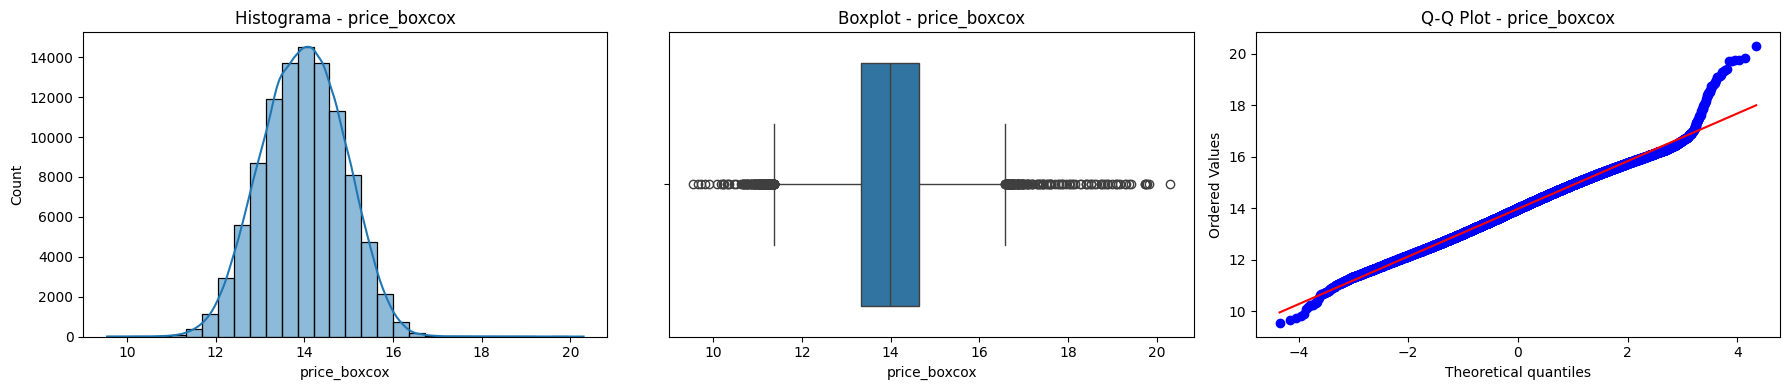

,Variable,Skew,Q1,Median,Q3,IQR,Lower bound,Upper bound,Lower whisker,Upper whisker,Outlier count,Min outlier,Max outlier
0,price_original,0.986644,1503.990000,1863.990000,2287.990000,784.000000,327.990000,3463.990000,372.990000,3462.990000,976,3463.990000,10984.990000
1,price_log,-0.133105,7.315877,7.530475,7.735429,0.419552,6.686549,8.364757,6.687096,8.364739,386,5.921552,9.304285
2,price_sqrt,0.332253,38.781310,43.173950,47.832938,9.051629,25.203867,61.410381,25.238661,61.408387,364,19.312949,104.809303
3,price_boxcox,-0.000238,13.332762,13.988255,14.634359,1.301598,11.380365,16.586756,11.383100,16.584361,317,9.552411,20.298790


In [ ]:
def analyze_variable(name, series):
    series = pd.Series(series).dropna()
    Q1 = series.quantile(0.25)
    median = series.median()
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    lower_whisker = series[series >= lower_bound].min()
    upper_whisker = series[series <= upper_bound].max()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Histogram
    sns.histplot(series, bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram - {name}")
    axes[0].set_xlabel(name)

    # Boxplot
    sns.boxplot(x=series, ax=axes[1])
    axes[1].set_title(f"Boxplot - {name}")
    axes[1].set_xlabel(name)

    # Q-Q Plot
    probplot(series, dist="norm", plot=axes[2])
    axes[2].set_title(f"Q-Q Plot - {name}")

    plt.tight_layout()
    plt.show()

    return {
        "Variable": name,
        "Skew": series.skew(),
        "Q1": Q1,
        "Median": median,
        "Q3": Q3,
        "IQR": IQR,
        "Lower bound": lower_bound,
        "Upper bound": upper_bound,
        "Lower whisker": lower_whisker,
        "Upper whisker": upper_whisker,
        "Outlier count": len(outliers),
        "Min outlier": outliers.min() if len(outliers) > 0 else None,
        "Max outlier": outliers.max() if len(outliers) > 0 else None
    }


results = []

for col in price_comparison.columns:
    result = analyze_variable(col, price_comparison[col])
    results.append(result)

summary_transform = pd.DataFrame(results)
summary_transform

**Result:** Box-Cox is the best transformation. It brings the skew closest to zero (−0.0002, versus 0.99 for the original price, −0.13 for log and 0.33 for square root) and reduces the number of outliers from 976 in the original variable to 317 (log: 386, square root: 364).

In [ ]:
continuous_vars = ["weight_kg", "power_watts", "price"]
boxcox_final = PowerTransformer(method="box-cox", standardize=False)

computers_transf[continuous_vars] = boxcox_final.fit_transform(
    computers_transf[continuous_vars]
)

print("Box-Cox transformation applied to:")
print(continuous_vars)

Box-Cox transformation applied to:
['weight_kg', 'power_watts', 'price']


In [ ]:
print("\nSkew after applying Box-Cox:")
display(computers_transf[continuous_vars].skew())


Skew after applying Box-Cox:


,0
weight_kg,0.213748
power_watts,0.086581
price,-0.000238


---

## 7. Scaling numeric variables

Apply `MinMaxScaler` to every numeric column so that all variables share the same [0, 1] scale, replacing the original columns.

In [ ]:
num_cols_transf = computers_transf.select_dtypes(include='number').columns.tolist()
scaler = MinMaxScaler()
computers_transf[num_cols_transf] = scaler.fit_transform(computers_transf[num_cols_transf])

print('Numeric variables scaled to [0, 1]:')
print(computers_transf[num_cols_transf].describe().T[['min', 'max']])

Numeric variables scaled to [0, 1]:
                     min  max
cpu_tier             0.0  1.0
cpu_threads          0.0  1.0
gpu_tier             0.0  1.0
vram_gb              0.0  1.0
storage_gb           0.0  1.0
storage_drive_count  0.0  1.0
bluetooth            0.0  1.0
weight_kg            0.0  1.0
warranty_months      0.0  1.0
price                0.0  1.0
years_since_release  0.0  1.0
power_watts          0.0  1.0


---

## 8. Ordinal encoding of `wifi`

Although `wifi` is categorical, its categories have a natural order (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7), so it is encoded with `OrdinalEncoder` and then scaled to [0, 1] with `MinMaxScaler` to match the other numeric variables. Both steps are applied in place, leaving a single `wifi` column.

In [ ]:
# Ordinal encoding with the natural Wi-Fi generation order
wifi_order = [['Wi-Fi 5', 'Wi-Fi 6', 'Wi-Fi 6E', 'Wi-Fi 7']]
oe = OrdinalEncoder(categories=wifi_order)
computers_transf['wifi'] = oe.fit_transform(computers_transf[['wifi']])

# Scale the encoded values to [0, 1]
mms_wifi = MinMaxScaler()
computers_transf['wifi'] = mms_wifi.fit_transform(computers_transf[['wifi']])

print('Unique wifi values after encoding and scaling:')
print([float(v) for v in sorted(computers_transf['wifi'].unique())])

Unique wifi values after encoding and scaling:
[0.0, 0.3333333333333333, 0.6666666666666666, 1.0]


---

## 9. Binary encoding of `gpu_model`

`gpu_model` has many categories (49), so one-hot encoding would significantly increase the dimensionality of the dataframe. `BinaryEncoder` is used instead, and the result is stored in `bin_df` to be merged with `computers_transf` later.

In [ ]:
# Binary-encode gpu_model
be = BinaryEncoder(cols=['gpu_model'])
bin_df = be.fit_transform(computers_transf[['gpu_model']])
print(f'Columns generated by BinaryEncoder: {bin_df.shape[1]}')
bin_df.head()

Columns generated by BinaryEncoder: 6


,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5
0,0,0,0,0,0,1
1,0,0,0,0,1,0
2,0,0,0,0,1,1
3,0,0,0,1,0,0
4,0,0,0,1,0,1


---

## 10. One-hot encoding and final dataset

**Goals**
- Encode the remaining categorical variables with `OneHotEncoder`, using `drop='first'` to avoid multicollinearity. Store the result in `ohe_df`.
- Combine `computers_transf` with the encoded variables in `bin_df` and `ohe_df`, dropping the original categorical columns.
- Verify with `describe()` that every column lies between 0 and 1 and that no categorical variables remain.

In [ ]:
# Remaining categorical columns (wifi and gpu_model are already encoded)
remaining_cat = [c for c in computers_transf.select_dtypes(include='object').columns
                 if c not in ['gpu_model', 'wifi']]
print('Variables to encode with OHE:', remaining_cat)

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe_array = ohe.fit_transform(computers_transf[remaining_cat])
ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(remaining_cat),
                      index=computers_transf.index)
print('ohe_df shape:', ohe_df.shape)

# Replace the original categorical columns with their encoded versions
cols_to_drop = remaining_cat + ['gpu_model']
computers_transf = pd.concat([
    computers_transf.drop(columns=cols_to_drop),
    bin_df,
    ohe_df
], axis=1)

computers_transf.shape

Variables to encode with OHE: ['device_type', 'brand', 'os', 'form_factor', 'cpu_brand', 'gpu_brand', 'storage_type', 'display_type']
ohe_df shape: (100000, 35)


(100000, 54)

In [ ]:
# Final verification
desc = computers_transf.describe().T
print('=== Verification: min and max of every column ===')
print(desc[['min', 'max']].to_string())

cat_remaining = computers_transf.select_dtypes(include='object').columns.tolist()
print(f'\nUncoded categorical variables: {cat_remaining}')

=== Verification: min and max of every column ===
                         min  max
cpu_tier                 0.0  1.0
cpu_threads              0.0  1.0
gpu_tier                 0.0  1.0
vram_gb                  0.0  1.0
storage_gb               0.0  1.0
storage_drive_count      0.0  1.0
wifi                     0.0  1.0
bluetooth                0.0  1.0
weight_kg                0.0  1.0
warranty_months          0.0  1.0
price                    0.0  1.0
years_since_release      0.0  1.0
power_watts              0.0  1.0
gpu_model_0              0.0  1.0
gpu_model_1              0.0  1.0
gpu_model_2              0.0  1.0
gpu_model_3              0.0  1.0
gpu_model_4              0.0  1.0
gpu_model_5              0.0  1.0
device_type_Laptop       0.0  1.0
brand_Acer               0.0  1.0
brand_Apple              0.0  1.0
brand_Dell               0.0  1.0
brand_Gigabyte           0.0  1.0
brand_HP                 0.0  1.0
brand_Lenovo             0.0  1.0
brand_MSI                0.0  1.

**Result:** the final dataset has 100,000 rows and 54 columns, all numeric and scaled to [0, 1].

---

## 11. Notes and next steps

- **Data leakage.** All transformers (`KBinsDiscretizer`, `PowerTransformer`, `MinMaxScaler` and the encoders) are fitted on the full dataset. For model evaluation, split into train and test sets first and fit the transformations on the training data only (e.g., inside a `ColumnTransformer` / `Pipeline`).
- **Target transformation.** `price` is Box-Cox transformed and min-max scaled. Predictions must be inverse-transformed (`scaler`, then `boxcox_final`) to report prices in their original units.
- **Redundancy criterion.** The 0.9 correlation threshold is a heuristic. `ram_gb` is likely informative for price, so it is worth validating this decision by comparing model performance with and without it.
- **Transformation choice.** Box-Cox was selected by looking at `price` only and then applied to `weight_kg` and `power_watts` as well; their skew after the transformation (0.21 and 0.09) confirms the choice is reasonable.

---

## AI usage statement

- OpenAI. (2026). *ChatGPT* [Large language model]. Used for spelling review and documentation support.
- Anthropic. (2026). *Claude* (claude-sonnet-5-5) [Large language model]. Used to translate the notebook into English and to format its documentation.